# Fine-tuning Aurora on CMIP6 data

This notebook demonstrates fine-tuning of the [Aurora](https://microsoft.github.io/aurora/) weather foundation model (1.3 B parameters, pretrained mostly on ERA5 reanalysis) with CMIP6 data (MPI-ESM), using one month of 6-hourly output regridded to Aurora's native 0.25° grid by the [regrid](https://github.com/alan-turing-institute/regrid) Snakemake workflow.

The demo includes:

1. **Interactive CPU inference** (this notebook): load the base and fine-tuned models,
   make a forecast, look at maps.
2. **Real GPU training on ORCHID** (JASMIN's A100 cluster): submitted from this
   notebook with `sbatch`, monitored here by reading the TensorBoard logs.
3. **Precomputed evaluation**: multi-day rollouts of both models against the CMIP6
   ground truth were computed offline by `slurm_scripts/evaluate.sbatch`; here we only load
   and plot the results.

### Setup

Run this notebook from the repo root with the `aurora-demo` kernel or `conda activate ./mamba-env`.
The heavy cells are guarded by flags in the next cell - the full-model CPU forecast takes ~2 minutes and ~10 GB of RAM per forward pass (measured on 16 cores of a LOTUS node), so it should be OK on a sci- VM.
Set `RUN_CPU_INFERENCE = False` if you are somewhere very small.


In [ ]:
from pathlib import Path

REPO = Path.cwd()
assert (REPO / "train.py").exists(), "Run this notebook from the repo root"

# Heavy / stateful cells are opt-in:
RUN_CPU_INFERENCE = True    # full-model forecast on CPU: ~30 GB RAM, a few minutes
SUBMIT_TRAINING = False     # submit a real 1-GPU fine-tuning job to ORCHID cluster
RUN_CPU_TRAIN_STEP = False  # appendix: one training step of the small model on CPU

import logging
logging.basicConfig(level=logging.WARNING)  # quieten the data-loading chatter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from inference import (
    LazyCMIP6Data, load_finetuned, compute_metrics, surf_field, atmos_field,
)

FINETUNED_CKPT = REPO / "checkpoints/gpu/epoch-0004.pt"  # 4 epochs of full fine-tuning
EVAL_DIR = REPO / "eval_results"
EVAL_DIR

## 1. One month of a CMIP6 climate data

The Snakemake workflow (see the regrid [repo](https://github.com/alan-turing-institute/regrid)) subsets MPI-ESM CMIP6 output from the CEDA archive (`/badc`), interpolates it to Aurora's 13 pressure levels, regrids it bilinearly to the regular 0.25° grid (721 × 1440), and renames everything to the ERA5-style names Aurora expects.
`inference.LazyCMIP6Data` opens the result lazily, so peeking at it costs almost nothing (unlike the training dataset class, which materialises ~36 GB).

In [2]:
data = LazyCMIP6Data(REPO / "data")
print(f"{len(data)} six-hourly timesteps: {data.valid_time[0]} .. {data.valid_time[-1]}")
print(f"grid: {len(data.lat)} x {len(data.lon)} (0.25 deg), levels (hPa): {data.atmos_levels}")

125 six-hourly timesteps: 1850-01-01 06:00:00 .. 1850-02-01 06:00:00
grid: 721 x 1440 (0.25 deg), levels (hPa): (50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000)


In [5]:
# A small plotting helper: pcolormesh with coastlines if cartopy works, else plain imshow.
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    def field_axes(fig, rows, cols, index):
        ax = fig.add_subplot(rows, cols, index, projection=ccrs.PlateCarree(central_longitude=180))
        ax.coastlines(linewidth=0.5)
        return ax

    def plot_field(ax, values, lat, lon, title, cmap="RdYlBu_r", **kw):
        mesh = ax.pcolormesh(lon, lat, values, transform=ccrs.PlateCarree(),
                             cmap=cmap, rasterized=True, **kw)
        ax.set_title(title, fontsize=10)
        return mesh
except Exception:  # cartopy missing or no Natural Earth data: fall back to imshow
    def field_axes(fig, rows, cols, index):
        return fig.add_subplot(rows, cols, index)

    def plot_field(ax, values, lat, lon, title, cmap="RdYlBu_r", **kw):
        mesh = ax.imshow(values, origin="upper", cmap=cmap,
                         extent=[lon.min(), lon.max(), lat.min(), lat.max()], **kw)
        ax.set_title(title, fontsize=10)
        return mesh


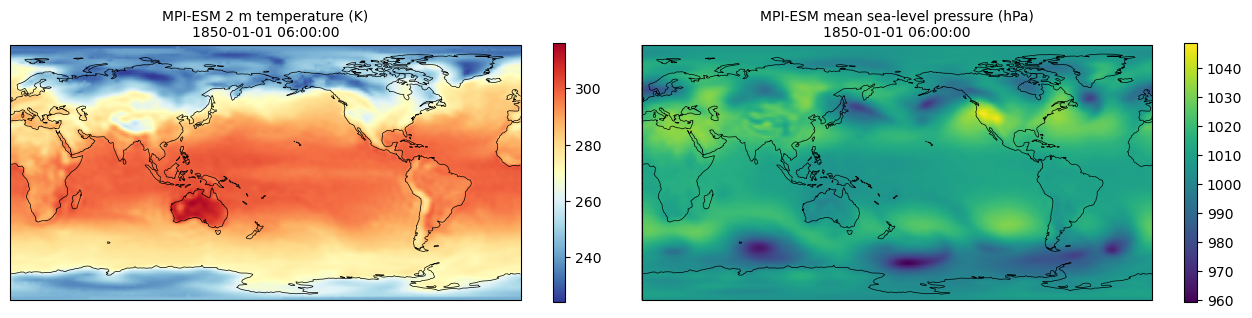

In [ ]:
# Check that we can plot some variables.

snapshot = data.truth_at(0)
lat, lon = data.lat.numpy(), data.lon.numpy()

fig = plt.figure(figsize=(13, 4))
for i, (label, values, cmap) in enumerate([
    ("2 m temperature (K)", surf_field(snapshot, "2t"), "RdYlBu_r"),
    ("mean sea-level pressure (hPa)", surf_field(snapshot, "msl") / 100, "viridis"),
], start=1):
    ax = field_axes(fig, 1, 2, i)
    mesh = plot_field(ax, values, lat, lon, f"MPI-ESM {label}\n{data.valid_time[0]}", cmap=cmap)
    fig.colorbar(mesh, ax=ax, shrink=0.7)
plt.tight_layout()


## 2. Base Aurora vs fine-tuned Aurora

Aurora takes the atmospheric state at two consecutive times (here *t*−6 h and *t*) and
predicts the full state at *t*+6 h; applied autoregressively that gives a forecast of any
length. We now make one 6-hour prediction with

* the **base model** - Microsoft's pretrained 0.25° checkpoint (knows Earth's weather from
  ERA5, has never seen MPI-ESM), and
* the **fine-tuned model** - the same architecture after 4 epochs of full fine-tuning on
  this month of MPI-ESM output, from `checkpoints/gpu/epoch-0004.pt` (trained on ORCHID
  by `train.py`; the 15 GB checkpoint also stores the optimizer state, which we leave
  on disk via `mmap`).

A single forward pass of the 1.3 B-parameter model at 0.25° takes about two minutes on
16 CPU cores (and under 10 GB of RAM in inference mode).


In [ ]:
INIT_INDEX = 0  # forecast initialised at data.valid_time[INIT_INDEX + 1]

if RUN_CPU_INFERENCE:
    from aurora import AuroraPretrained

    input_batch = data.batch_at(INIT_INDEX)      # history = timesteps 0 and 1
    truth = data.truth_at(INIT_INDEX + 2)        # verification at +6 h
    print("forecast start:", input_batch.metadata.time[0])

    model = AuroraPretrained()
    model.load_checkpoint()   # cached under ~/.cache/huggingface
    model.eval()

    with torch.inference_mode():
        pred_base = model.forward(input_batch)
    print("base model forward done")


forecast start: 1850-01-01 12:00:00


In [6]:
if RUN_CPU_INFERENCE:
    # Load the fine-tuned weights into the *same* model object (saves ~5 GB of RAM),
    # then repeat the identical forecast.
    load_finetuned(model, FINETUNED_CKPT)
    model.eval()

    with torch.inference_mode():
        pred_finetuned = model.forward(input_batch)
    print("fine-tuned model forward done")


fine-tuned model forward done


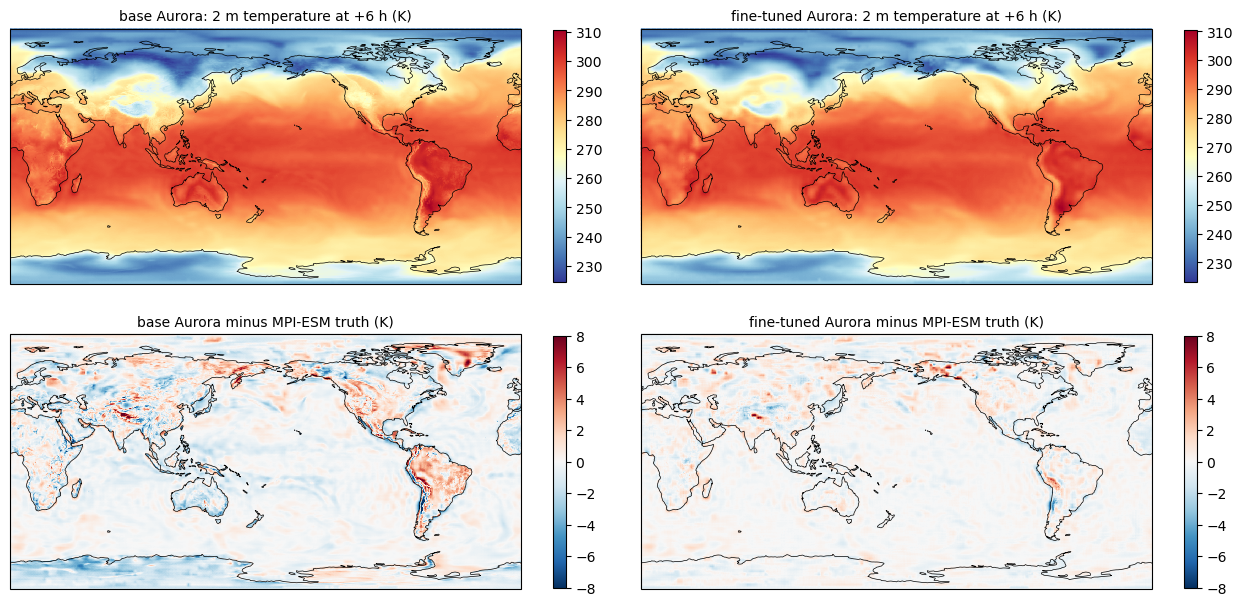

In [7]:
if RUN_CPU_INFERENCE:
    var = "2t"
    t_truth = surf_field(truth, var)
    crop = lambda a: a[: pred.shape[0], : pred.shape[1]]

    fig = plt.figure(figsize=(13, 6.5))
    panels = [("base Aurora", surf_field(pred_base, var)),
              ("fine-tuned Aurora", surf_field(pred_finetuned, var))]
    for i, (name, pred) in enumerate(panels):
        ax = field_axes(fig, 2, 2, i + 1)
        mesh = plot_field(ax, pred, lat[: pred.shape[0]], lon[: pred.shape[1]],
                          f"{name}: 2 m temperature at +6 h (K)")
        fig.colorbar(mesh, ax=ax, shrink=0.8)
        ax2 = field_axes(fig, 2, 2, i + 3)
        err = pred - crop(t_truth)
        mesh = plot_field(ax2, err, lat[: pred.shape[0]], lon[: pred.shape[1]],
                          f"{name} minus MPI-ESM truth (K)", cmap="RdBu_r",
                          vmin=-8, vmax=8)
        fig.colorbar(mesh, ax=ax2, shrink=0.8)
    plt.tight_layout()


In [8]:
if RUN_CPU_INFERENCE:
    # Latitude-weighted scores for this single 6 h forecast, per variable.
    rows = []
    for name, pred in [("base", pred_base), ("finetuned", pred_finetuned)]:
        for rec in compute_metrics(pred, truth):
            rows.append({"model": name, **rec})
    scores = pd.DataFrame(rows)
    surface_scores = scores[scores.level.isna()].pivot(index="var", columns="model", values="rmse")
    z500 = scores[(scores["var"] == "z") & (scores.level == 500)].pivot(
        index="var", columns="model", values="rmse")
    display(pd.concat([surface_scores, z500]).round(3))


model,base,finetuned
var,,
10u,1.200,0.626
10v,1.131,0.566
2t,1.162,0.590
msl,103.703,29.315
z,47.604,17.983


## 3. Fine-tuning on ORCHID

Training does need a GPU: one epoch over this month (123 optimizer steps) of full
fine-tuning takes roughly an hour on a single A100, using chunked activation
checkpointing so the 1.3 B-parameter model plus
AdamW state fits on one 40 GB card. `train.py` implements the loop: the
variable-weighted mean-absolute-error loss from the Aurora paper (`aurora_loss.py`),
AdamW at 3 × 10⁻⁵, one checkpoint per epoch, and TensorBoard logging. It also supports
`--lora`, `--adam8bit` and DeepSpeed ZeRO - see `slurm_scripts/` for variants.

This notebook doesn't train anything itself - it submits the same batch job you would
submit from a terminal, then watches the logs. Set `SUBMIT_TRAINING = True` in the first
code cell to actually submit (it queues a ~1 h, 1-GPU job on the `orchid` partition).


In [ ]:
import shutil, subprocess

SLURM_HOST = "sci-vm-04.jasmin.ac.uk"  # fallback if this machine has no slurm client

def slurm(*args):
    """Run a slurm command locally, or via ssh if this host has no slurm client."""
    if shutil.which(args[0]):
        result = subprocess.run(list(args), capture_output=True, text=True, cwd=REPO)
    else:
        remote = f"cd {REPO} && " + " ".join(args)
        result = subprocess.run(["ssh", SLURM_HOST, remote], capture_output=True, text=True)
    output = (result.stdout + result.stderr).strip()
    print(output)
    return output

demo_job_id = None
if SUBMIT_TRAINING:
    reply = slurm("sbatch", "slurm_scripts/demo_train.sbatch")
    demo_job_id = reply.split()[-1] if "Submitted" in reply else None

Submitted batch job 41756752


In [3]:
# Re-run this cell at any time to check the queue / running jobs.
slurm("squeue", "--me", "-o", "%.10i %.22j %.9P %.8T %.10M %R");


JOBID                   NAME PARTITION    STATE       TIME NODELIST(REASON)
  41751474  Aurora demo fine-tune    orchid  RUNNING       9:35 gpuhost013
  41756752  Aurora demo fine-tune    orchid  RUNNING       0:15 gpuhost015


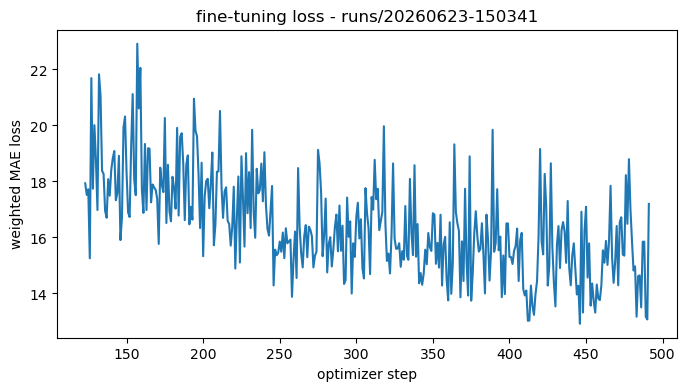

In [11]:
# Live loss curve, read straight from the TensorBoard event files that train.py writes.
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_scalars(run_dir, tag="train/loss"):
    if not Path(run_dir).is_dir():
        return None
    acc = EventAccumulator(str(run_dir))
    acc.Reload()
    if tag not in acc.Tags().get("scalars", []):
        return None
    events = acc.Scalars(tag)
    return pd.DataFrame({"step": [e.step for e in events], tag: [e.value for e in events]})

# Prefer the job this notebook submitted; otherwise fall back to the most recent run.
run_dirs = ([REPO / "runs" / f"demo-{demo_job_id}"] if demo_job_id else []) + sorted(
    (REPO / "runs").glob("*"), reverse=True)
loss = run_dir = None
for run_dir in run_dirs:
    loss = read_scalars(run_dir)
    if loss is not None and len(loss) > 1:
        break

if loss is None:
    print("No train/loss events found yet - re-run this cell once training has started.")
else:
    ax = loss.plot(x="step", y="train/loss", figsize=(8, 4), legend=False,
                   title=f"fine-tuning loss - runs/{run_dir.name}")
    ax.set_xlabel("optimizer step"); ax.set_ylabel("weighted MAE loss")


In [ ]:
# Throughput (steps/sec) for the same run, using the perf/* scalars train.py writes.
throughput = read_scalars(run_dir, tag="perf/steps_per_second") if run_dir else None

if throughput is None:
    print("No perf/steps_per_second events found yet for this run.")
else:
    ax = throughput.plot(x="step", y="perf/steps_per_second", figsize=(8, 4), legend=False,
                          title=f"training throughput - runs/{run_dir.name}")
    ax.set_xlabel("optimizer step"); ax.set_ylabel("steps / second")

In [ ]:
# Compare benchmark_summary.json across benchmark_train.sbatch runs, without needing TensorBoard.
import json

def flag_enabled(cli_args, no_flag_key, old_flag_key):
    """train.py renamed --tf32/--autocast to --no-tf32/--no-autocast (default on) on
    2026-07-31; this reads the new negated flag if present, else the old direct one
    (absent/False on runs from before either flag existed at all)."""
    if no_flag_key in cli_args:
        return not cli_args[no_flag_key]
    return cli_args.get(old_flag_key, False)

def flatten_summary(path):
    summary = json.loads(path.read_text())
    metadata = summary.pop("metadata", {})
    cli_args = metadata.get("cli_args", {})
    git_info = metadata.get("git", {})
    commit = git_info.get("commit")
    return {
        "run": path.parent.name,
        "model": "small" if cli_args.get("use_small") else "standard",
        "tf32": flag_enabled(cli_args, "no_tf32", "tf32"),
        "autocast": flag_enabled(cli_args, "no_autocast", "autocast"),
        "commit": commit[:8] if commit else None,
        "dirty": git_info.get("dirty"),
        "gpu_name": metadata.get("gpu_name"),
        "slurm_job_id": metadata.get("slurm", {}).get("job_id"),
        **summary,
    }

summary_paths = sorted((REPO / "runs").glob("benchmark-*/benchmark_summary.json"))
summaries = None

if not summary_paths:
    print("No benchmark_summary.json files found yet - submit slurm_scripts/benchmark_train.sbatch.")
else:
    summaries = pd.DataFrame([flatten_summary(path) for path in summary_paths]).set_index("run")
    summaries = summaries[[
        "model", "tf32", "autocast", "commit", "dirty", "gpu_name", "slurm_job_id",
        "max_steps", "steps_per_second", "peak_host_rss_mib", "peak_gpu_allocated_mib",
        "peak_gpu_reserved_mib", "total_seconds",
    ]]
summaries

The curve above is the actual optimisation signal: the weighted MAE across all nine
variables. The big drop in the first few dozen steps is the model adapting from ERA5's
climate to MPI-ESM's (different land model, different SSTs, pre-industrial forcing) -
exactly the adaptation quantified properly in the next section.


## 4. Did fine-tuning help?

`evaluate.py` (submitted as `sbatch slurm_scripts/evaluate.sbatch`, ~30 min on one A100)
ran **5-day autoregressive rollouts** (20 × 6 h steps) from 6 initialisation times spread
across the month, for four "models":

| model | what it is |
|---|---|
| `base` | pretrained Aurora, zero-shot on MPI-ESM |
| `finetuned` | + 4 epochs of fine-tuning on this month |
| `persistence` | forecast = initial state, at every lead time |
| `climatology` | forecast = monthly-mean state |

Every forecast is scored against the MPI-ESM fields with latitude-weighted RMSE, per
variable and pressure level. Persistence and climatology are the classic sanity
baselines: a model with any skill must beat persistence at short leads and climatology
at long leads.

> **Caveat, stated openly:** the fine-tuning month and evaluation month are the same
> (we only regridded one month so far), so this measures *how well Aurora adapted to
> the target model's climate*, not out-of-sample forecast skill. The next step -
> regridding a held-out period and re-running `evaluate.sbatch` on it - needs no new
> code, just more data through the Snakemake workflow.


In [12]:
metrics_path = EVAL_DIR / "metrics.csv"
assert metrics_path.exists(), (
    "No evaluation results yet - run: sbatch slurm_scripts/evaluate.sbatch")
metrics = pd.read_csv(metrics_path)
metrics["level"] = metrics["level"].astype("Int64")
print(f"{len(metrics)} rows | models: {sorted(metrics.model.unique())} | "
      f"{metrics.init_time.nunique()} inits | leads up to {metrics.lead_hours.max()} h")
metrics.head()


33120 rows | models: ['base', 'climatology', 'finetuned', 'persistence'] | 6 inits | leads up to 120 h


,model,init_time,lead_hours,var,level,rmse,mae,bias
0,base,1850-01-01 12:00:00,6,2t,<NA>,1.161552,0.738538,-0.183251
1,base,1850-01-01 12:00:00,6,10u,<NA>,1.200422,0.832233,-0.093094
2,base,1850-01-01 12:00:00,6,10v,<NA>,1.131475,0.806046,-0.014204
3,base,1850-01-01 12:00:00,6,msl,<NA>,103.713835,59.094349,3.969934
4,base,1850-01-01 12:00:00,6,t,50,0.891066,0.687207,0.128499


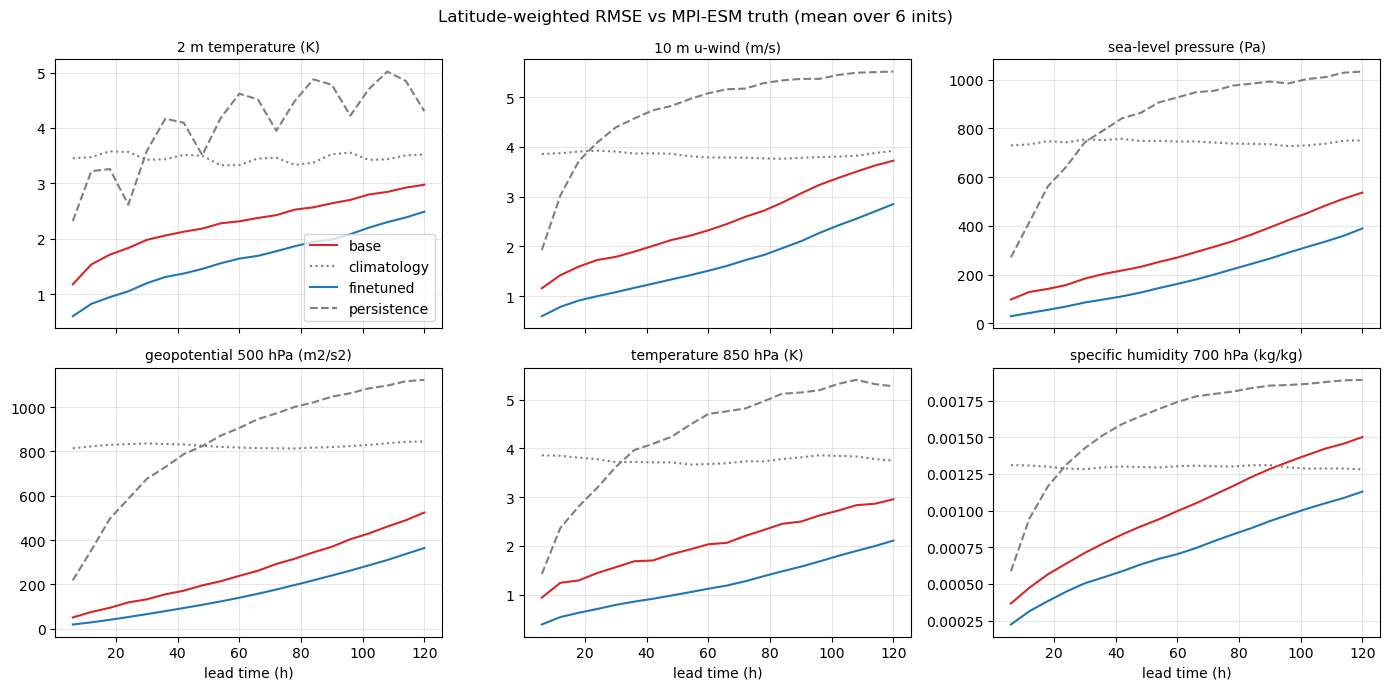

In [13]:
# RMSE vs lead time, averaged over initialisations.
HEADLINE = [("2t", None, "2 m temperature (K)"), ("10u", None, "10 m u-wind (m/s)"),
            ("msl", None, "sea-level pressure (Pa)"), ("z", 500, "geopotential 500 hPa (m2/s2)"),
            ("t", 850, "temperature 850 hPa (K)"), ("q", 700, "specific humidity 700 hPa (kg/kg)")]
STYLE = {"base": ("tab:red", "-"), "finetuned": ("tab:blue", "-"),
         "persistence": ("tab:gray", "--"), "climatology": ("tab:gray", ":")}

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for ax, (var, level, label) in zip(axes.flat, HEADLINE):
    sel = metrics[(metrics["var"] == var) &
                  (metrics.level.isna() if level is None else (metrics.level == level))]
    mean = sel.groupby(["model", "lead_hours"]).rmse.mean().reset_index()
    for model, grp in mean.groupby("model"):
        color, ls = STYLE.get(model, ("k", "-"))
        ax.plot(grp.lead_hours, grp.rmse, ls, color=color, label=model)
    ax.set_title(label, fontsize=10)
    ax.grid(alpha=0.3)
axes[0, 0].legend()
for ax in axes[1]:
    ax.set_xlabel("lead time (h)")
fig.suptitle("Latitude-weighted RMSE vs MPI-ESM truth (mean over 6 inits)")
plt.tight_layout()


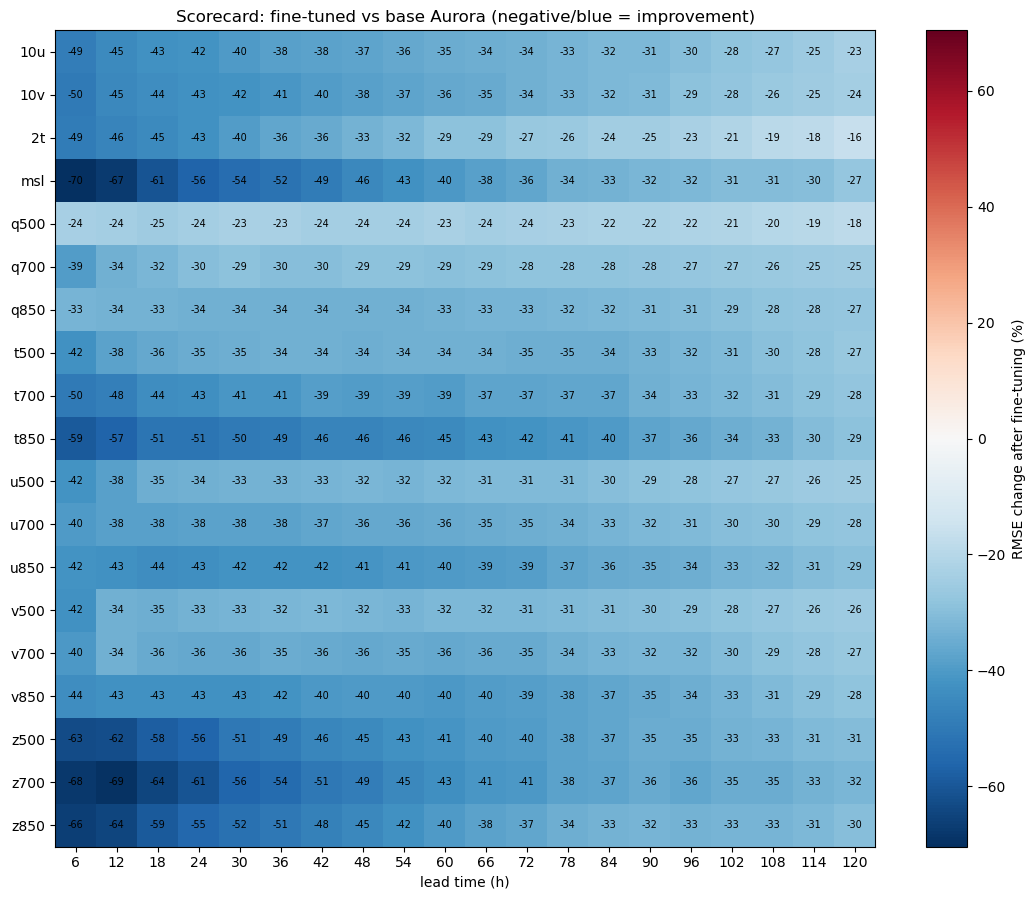

In [14]:
# Scorecard: percentage RMSE change of fine-tuned vs base, per variable x lead time.
# Blue = fine-tuning reduced the error.
surf = metrics[metrics.level.isna()].assign(name=lambda d: d["var"])
at_levels = metrics[metrics.level.isin([500, 700, 850])].assign(
    name=lambda d: d["var"] + d.level.astype(str))
both = pd.concat([surf, at_levels])
mean = both.groupby(["model", "name", "lead_hours"]).rmse.mean().unstack("model")
change = 100 * (mean["finetuned"] - mean["base"]) / mean["base"]
card = change.unstack("lead_hours")

fig, ax = plt.subplots(figsize=(11, 0.4 * len(card) + 1.5))
limit = np.nanmax(np.abs(card.values))
im = ax.imshow(card.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(card.shape[1]), card.columns)
ax.set_yticks(range(card.shape[0]), card.index)
ax.set_xlabel("lead time (h)")
for i in range(card.shape[0]):
    for j in range(card.shape[1]):
        ax.text(j, i, f"{card.values[i, j]:+.0f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="RMSE change after fine-tuning (%)")
ax.set_title("Scorecard: fine-tuned vs base Aurora (negative/blue = improvement)")
plt.tight_layout()


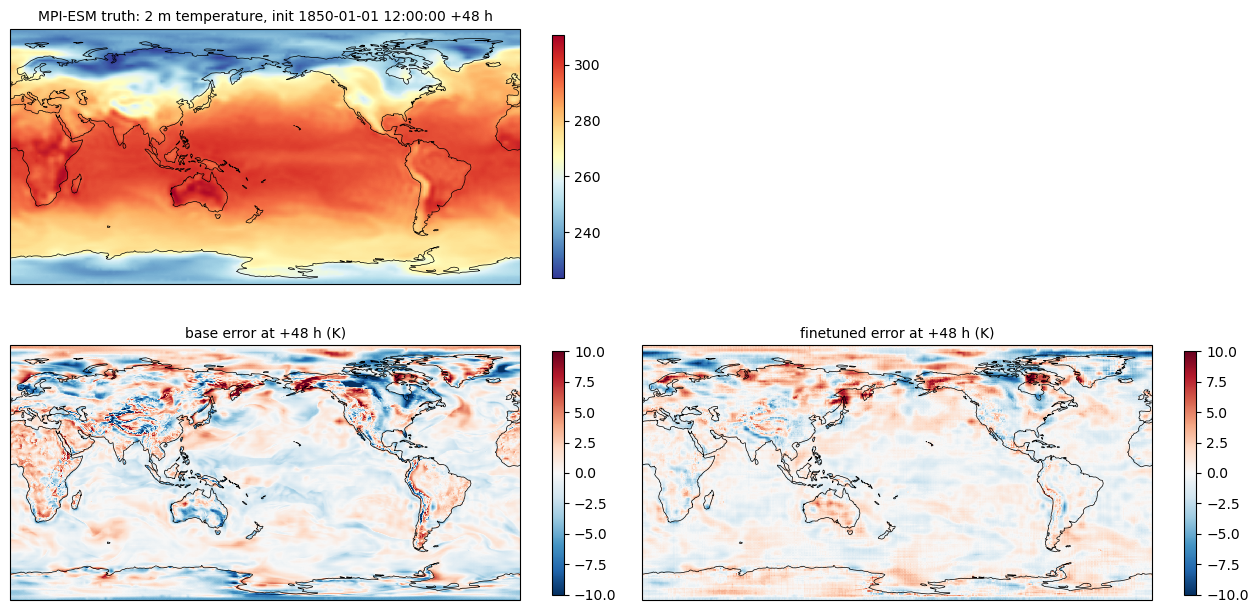

In [15]:
# Case-study maps from the saved fields: 48 h forecast of 2 m temperature.
import xarray as xr

LEAD = 48
fields = {name: xr.open_dataset(EVAL_DIR / f"fields_{name}.nc")
          for name in ("truth", "base", "finetuned")}
init_label = fields["truth"].attrs.get("init_time", "?")

fig = plt.figure(figsize=(13, 6.5))
truth48 = fields["truth"]["2t"].sel(lead_hours=LEAD)
ax = field_axes(fig, 2, 2, 1)
mesh = plot_field(ax, truth48.values, truth48.lat.values, truth48.lon.values,
                  f"MPI-ESM truth: 2 m temperature, init {init_label} +{LEAD} h")
fig.colorbar(mesh, ax=ax, shrink=0.8)
for i, name in enumerate(("base", "finetuned"), start=1):
    pred48 = fields[name]["2t"].sel(lead_hours=LEAD)
    ax = field_axes(fig, 2, 2, i + 2)
    mesh = plot_field(ax, (pred48 - truth48).values, pred48.lat.values, pred48.lon.values,
                      f"{name} error at +{LEAD} h (K)", cmap="RdBu_r", vmin=-10, vmax=10)
    fig.colorbar(mesh, ax=ax, shrink=0.8)
plt.tight_layout()


Typical things to look for above: the base model develops systematic errors where
MPI-ESM's climate differs from ERA5's (sea-ice edges, land surfaces, the Southern
Ocean), while the fine-tuned model's errors stay closer to flow-dependent noise.


## Appendix A: CPU training

To demystify `train.py`: this is the entire training loop for a single batch - forward
pass, the paper's weighted-MAE loss, backward pass, optimizer step. We use the *small*
Aurora variant (~113 M parameters) so it runs in about a minute on CPU. Set
`RUN_CPU_TRAIN_STEP = True` to run it.


In [16]:
if RUN_CPU_TRAIN_STEP:
    from aurora import AuroraSmallPretrained
    from aurora_loss import mae

    small = AuroraSmallPretrained()
    small.load_checkpoint()
    small.train()
    small.configure_activation_checkpointing()

    X = data.batch_at(0)
    y = data.truth_at(2)
    optimizer = torch.optim.AdamW([p for p in small.parameters() if p.requires_grad],
                                  lr=3e-5, weight_decay=0.01)
    optimizer.zero_grad(set_to_none=True)
    prediction = small(X)
    loss = mae(prediction, y)
    loss.backward()
    optimizer.step()
    print(f"one optimizer step done - weighted MAE loss: {loss.item():.3f}")


## Appendix B: Future work

* **Held-out evaluation**: extend `config/preprocess.yaml` to regrid a second month and
  point `evaluate.py --data_path` at it - that turns Section 4 into a genuine
  out-of-sample test.
* **More efficient fine-tuning**: `train.py --lora` (adapters only) and `--adam8bit`
  trade accuracy for memory/speed; DeepSpeed ZeRO configs live in `ds_configs/`.
* **Longer training**: `slurm_scripts/demo_train.sbatch` resumes from checkpoints via
  `--resume`, so more epochs are just more submissions.
* **Standard metrics at scale**: the metric definitions here follow
  [WeatherBench2](https://sites.research.google/weatherbench/); adopting its evaluation
  framework would let these scores sit next to published baselines (IFS, GraphCast, ...).
